In [1]:
# Imports, configuration, and shared styling for every figure in this notebook
import os
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import normalized_mutual_info_score

from networks import load_arm
from plot_style import (
    set_publication_style, style_axis, save_figure, format_date_axis, annotate_events,
    add_panel_label, REGIME_PALETTE, NEUTRAL_COLOURS, CRISIS_EVENTS,
)

INDEX_CODE = "SP500"
ARM = "raw"
EPOCH_LENGTH = 132
GRAPH_TYPES = ["threshold", "mst", "tmfg"]
GRAPH_KEYS = {"threshold": "threshold_graphs", "mst": "mst_threshold_graphs", "tmfg": "tmfg_threshold_graphs"}
GRAPH_LABELS = {"threshold": "Threshold", "mst": "MST-Threshold", "tmfg": "TMFG-Threshold"}
GRAPH_TYPE_COLOURS = {"threshold": "#7570b3", "mst": "#1b9e77", "tmfg": "#d95f02"}
REGIME_NAMES = ["Calm", "Transitional", "Crisis"]

SECTOR_LABELS = {
    "IT": "Information Technology", "HC": "Health Care", "FIN": "Financials",
    "CD": "Consumer Discretionary", "CS": "Communication Services", "IND": "Industrials",
    "CST": "Consumer Staples", "ENE": "Energy", "UTL": "Utilities", "RE": "Real Estate", "MAT": "Materials",
}

IMAGES_DIR = "images/network_diagnostics"
CLIQUE_ENUM_CAP = 20000

os.makedirs(IMAGES_DIR, exist_ok=True)
set_publication_style()

In [2]:
# Load the raw-arm S&P 500 T=132 network data and align VIX to each window's end-date
data = load_arm(ARM, EPOCH_LENGTH, index_code=INDEX_CODE)
stock_names = data["stock_names"]
epoch_dates = pd.DatetimeIndex(pd.to_datetime(data["epoch_dates"]))
mu_values = np.array(data["mu_values"])
print(f"{INDEX_CODE} / {ARM} / T={EPOCH_LENGTH}: {len(stock_names)} stocks, {len(epoch_dates)} windows, "
      f"{epoch_dates[0].date()} to {epoch_dates[-1].date()}")

vix = pd.read_csv("data/VIX_Close.csv", index_col=0, parse_dates=True).squeeze().sort_index()
vix_at_epoch = vix.reindex(vix.index.union(epoch_dates)).sort_index().ffill().reindex(epoch_dates)
print(f"VIX aligned to {vix_at_epoch.notna().sum()} / {len(epoch_dates)} windows")

SP500 / raw / T=132: 349 stocks, 629 windows, 2001-07-12 to 2026-07-06
VIX aligned to 629 / 629 windows


In [3]:
# Select one representative window per period: highest VIX (Crisis), lowest VIX (Calm), closest to VIX=22.5 (Transitional)
vix_values = vix_at_epoch.to_numpy()
crisis_idx = int(np.nanargmax(vix_values))
calm_idx = int(np.nanargmin(vix_values))
transitional_idx = int(np.nanargmin(np.abs(vix_values - 22.5)))
assert len({calm_idx, transitional_idx, crisis_idx}) == 3, "period windows collided -- widen the transitional target"

PERIODS = {"Calm": calm_idx, "Transitional": transitional_idx, "Crisis": crisis_idx}
for name, idx in PERIODS.items():
    print(f"{name:13s} -> {epoch_dates[idx].date()}  VIX={vix_values[idx]:.1f}  mu={mu_values[idx]:.3f}")

Calm          -> 2017-12-11  VIX=9.3  mu=0.119
Transitional  -> 2001-12-21  VIX=22.5  mu=0.190
Crisis        -> 2008-11-19  VIX=74.3  mu=0.549


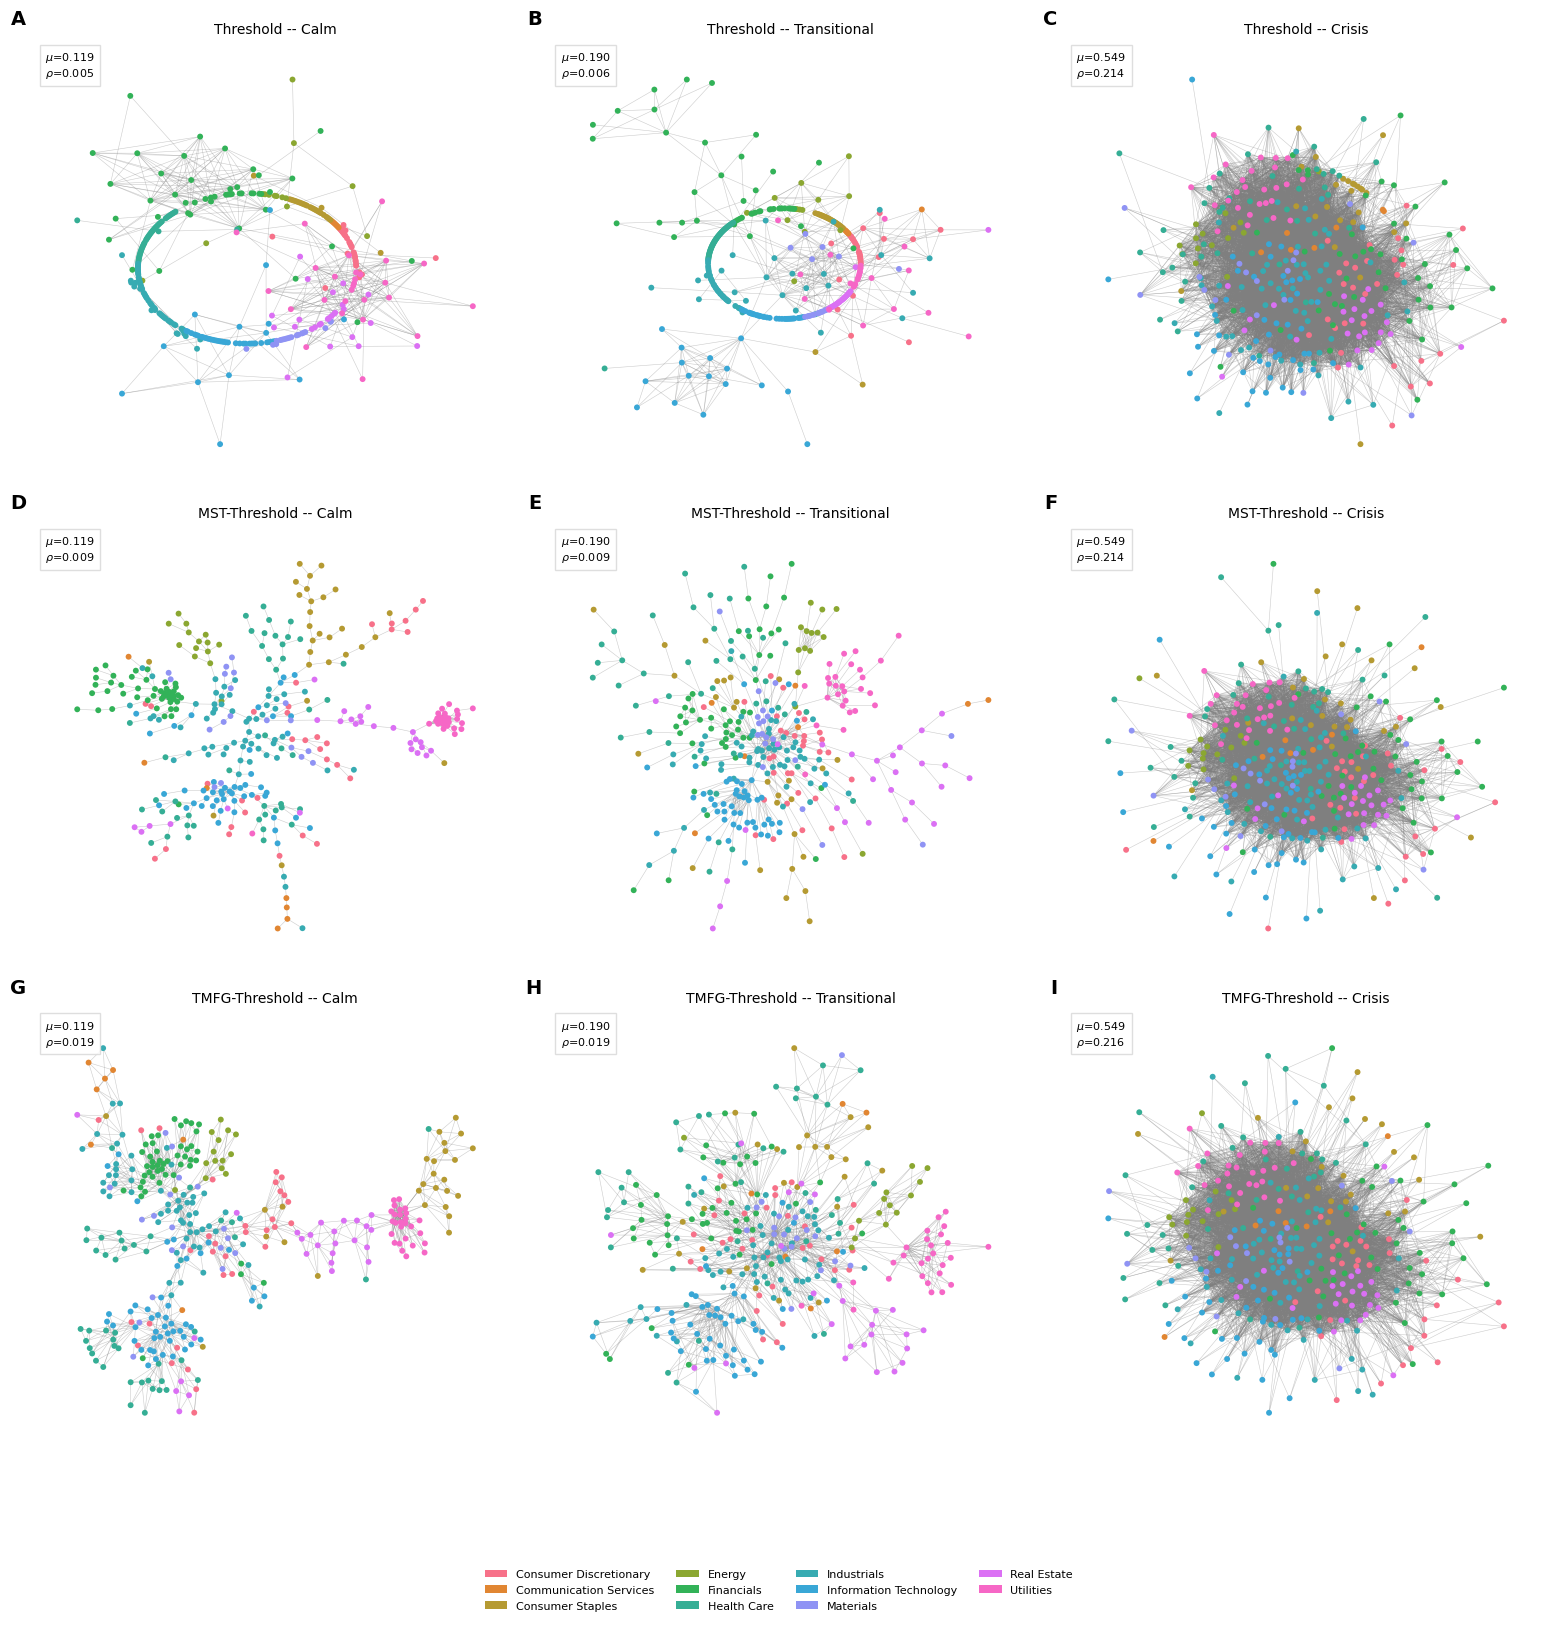

In [4]:
# Figure 1: 3x3 grid, node positions computed independently per panel, coloured by sector
sector_of = {s: s.split("_")[0] for s in stock_names}
unique_sectors = sorted(set(sector_of.values()))
sector_colour = dict(zip(unique_sectors, sns.color_palette("husl", len(unique_sectors))))
node_colour = [sector_colour[sector_of[s]] for s in stock_names]

fig, axes = plt.subplots(len(GRAPH_TYPES), len(PERIODS), figsize=(5.2 * len(PERIODS), 5.2 * len(GRAPH_TYPES)))
panel_letters = iter("ABCDEFGHI")

for row, graph_type in enumerate(GRAPH_TYPES):
    graph_key = GRAPH_KEYS[graph_type]
    period_graphs = {name: data[graph_key][idx] for name, idx in PERIODS.items()}

    for col, (period_name, G) in enumerate(period_graphs.items()):
        pos = nx.kamada_kawai_layout(G, weight="weight")
        ax = axes[row, col]
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color=NEUTRAL_COLOURS["reference"], width=0.4, alpha=0.4)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colour, node_size=18, linewidths=0)
        idx = PERIODS[period_name]
        ax.text(0.02, 0.98, f"$\\mu$={mu_values[idx]:.3f}\n$\\rho$={nx.density(G):.3f}", transform=ax.transAxes,
                va="top", fontsize=8, bbox=dict(facecolor="white", alpha=0.85, edgecolor=NEUTRAL_COLOURS["ci"]))
        add_panel_label(ax, next(panel_letters), x=-0.02, y=1.03)
        ax.set_title(f"{GRAPH_LABELS[graph_type]} -- {period_name}", fontsize=10)
        ax.axis("off")

sector_legend = [Patch(facecolor=sector_colour[s], label=SECTOR_LABELS.get(s, s)) for s in unique_sectors]
fig.legend(handles=sector_legend, loc="lower center", ncol=4, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=[0, 0.06, 1, 1])
save_figure(fig, f"{IMAGES_DIR}/network_structure_by_period.png")
plt.show()

In [5]:
# Compute density / component count / clustering coefficient / mean degree / NMI-vs-sector for every window, every construction
def window_topology_stats(G, n_nodes):
    return {
        "density": nx.density(G),
        "n_components": nx.number_connected_components(G),
        "avg_clustering": nx.average_clustering(G),
        "mean_degree": 2 * G.number_of_edges() / n_nodes,
    }


def nmi_vs_sector(G):
    communities = list(nx.algorithms.community.greedy_modularity_communities(G))
    node_to_comm = {node: cid for cid, comm in enumerate(communities) for node in comm}
    next_id = len(communities)
    for node in G.nodes():
        if node not in node_to_comm:
            node_to_comm[node] = next_id
            next_id += 1
    labels_pred = [node_to_comm[s] for s in stock_names]
    labels_true = [sector_of[s] for s in stock_names]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        return normalized_mutual_info_score(labels_true, labels_pred)


n_nodes = len(stock_names)
rows = []
for graph_type in GRAPH_TYPES:
    graph_key = GRAPH_KEYS[graph_type]
    for i, G in enumerate(data[graph_key]):
        stats = window_topology_stats(G, n_nodes)
        stats["nmi_sector"] = nmi_vs_sector(G)
        stats["graph_type"] = graph_type
        stats["date"] = epoch_dates[i]
        rows.append(stats)

topology_df = pd.DataFrame(rows)
print(f"computed topology stats for {len(topology_df)} (window x construction) rows")

computed topology stats for 1887 (window x construction) rows


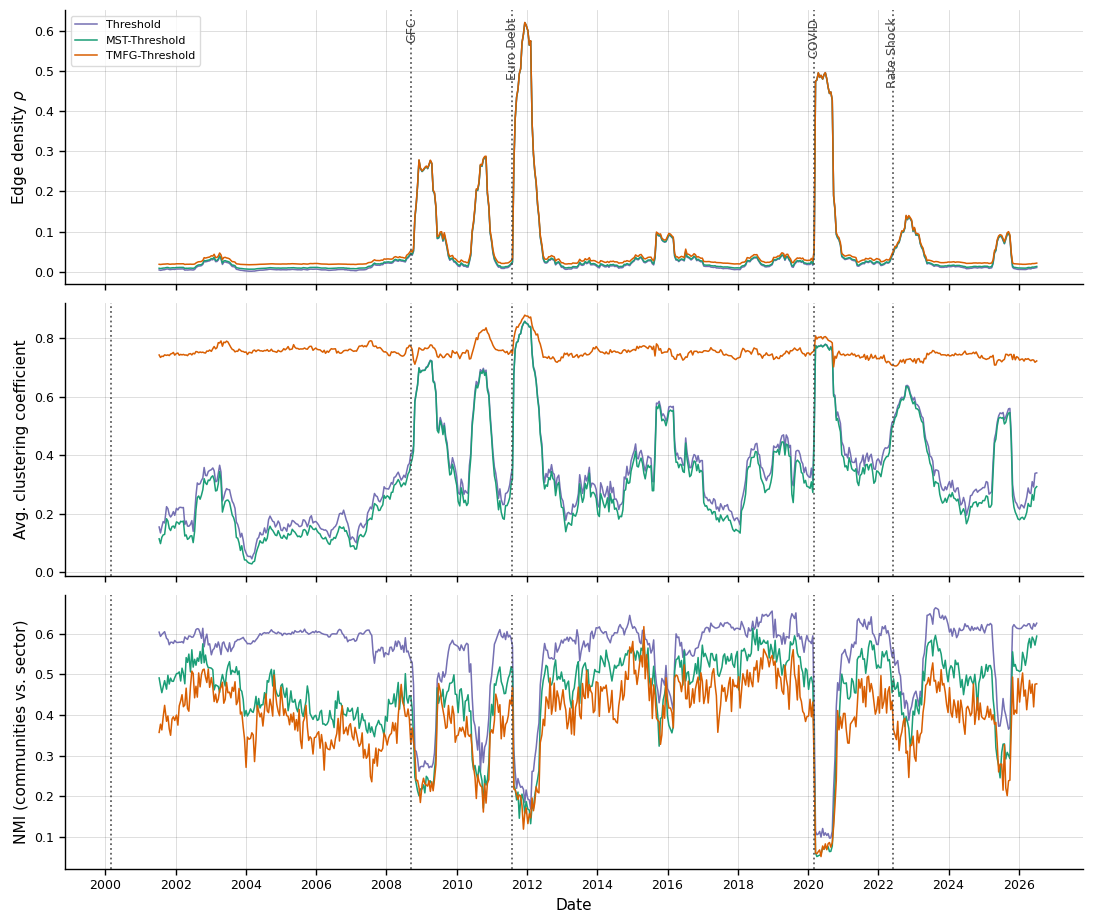

In [6]:
# Figure 2: three core metrics (mean_degree/n_components/LCC dropped as redundant with density; full stats retained in topology_df), stacked one above the other, one line per construction
metrics = [
    ("density", r"Edge density $\rho$"),
    ("avg_clustering", "Avg. clustering coefficient"),
    ("nmi_sector", "NMI (communities vs. sector)"),
]

fig, axes = plt.subplots(len(metrics), 1, figsize=(11, 3.1 * len(metrics)), sharex=True)
for row, (ax, (col, label)) in enumerate(zip(axes, metrics)):
    for graph_type in GRAPH_TYPES:
        sub = topology_df[topology_df["graph_type"] == graph_type]
        ax.plot(sub["date"], sub[col], color=GRAPH_TYPE_COLOURS[graph_type], linewidth=1.1, label=GRAPH_LABELS[graph_type])
    if row == 0:
        annotate_events(ax, CRISIS_EVENTS, epoch_dates[0], epoch_dates[-1])
    else:
        for date_str in CRISIS_EVENTS:
            ax.axvline(pd.to_datetime(date_str), color="#444444", linestyle=":", linewidth=1.3, alpha=0.85, zorder=4)
    ax.set_ylabel(label)
    format_date_axis(ax)
    style_axis(ax, grid=True)

axes[0].legend(loc="upper left", frameon=True, facecolor="white", edgecolor="lightgray", fontsize=8)
axes[-1].set_xlabel("Date")
plt.tight_layout()
save_figure(fig, f"{IMAGES_DIR}/topology_timeseries.png")
plt.show()

In [7]:
# Per-snapshot deep-dive stats: reuses topology_df for density/clustering/nmi instead of recomputing, adds capped clique enumeration, avg shortest path / diameter on LCC, degree assortativity
def clique_stats(G, cap=CLIQUE_ENUM_CAP):
    max_size = 0
    count = 0
    capped = False
    for c in nx.find_cliques(G):
        count += 1
        max_size = max(max_size, len(c))
        if count >= cap:
            capped = True
            break
    return max_size, count, capped


def lcc_subgraph(G):
    lcc_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(lcc_nodes)


topology_lookup = topology_df.set_index(["graph_type", "date"])

snapshot_rows = []
degree_by_panel = {}
for graph_type in GRAPH_TYPES:
    graph_key = GRAPH_KEYS[graph_type]
    for period_name, idx in PERIODS.items():
        G = data[graph_key][idx]
        Glcc = lcc_subgraph(G)
        max_clique, n_cliques, capped = clique_stats(G)
        stats = topology_lookup.loc[(graph_type, epoch_dates[idx])].to_dict()
        stats.update({
            "graph_type": GRAPH_LABELS[graph_type], "period": period_name,
            "avg_shortest_path_lcc": nx.average_shortest_path_length(Glcc),
            "diameter_lcc": nx.diameter(Glcc),
            "degree_assortativity": nx.degree_assortativity_coefficient(G),
            "largest_clique": max_clique,
            "n_maximal_cliques": f"{n_cliques}+" if capped else n_cliques,
        })
        snapshot_rows.append(stats)
        degree_by_panel[(graph_type, period_name)] = [d for _, d in G.degree()]

snapshot_df = pd.DataFrame(snapshot_rows).set_index(["graph_type", "period"])
snapshot_df = snapshot_df[["density", "n_components", "avg_clustering", "mean_degree",
                            "avg_shortest_path_lcc", "diameter_lcc", "degree_assortativity",
                            "largest_clique", "n_maximal_cliques", "nmi_sector"]]
print("Note: Crisis's largest_clique is enumeration-order-dependent (nx.find_cliques hits the 20,000-clique cap "
      "before exhausting the graph, and Python's hash randomization -- unset PYTHONHASHSEED -- reorders the "
      "capped search each process run), so its exact value can differ by a few units run-to-run; Calm/Transitional "
      "enumerate fully under the cap and are fully reproducible.")
snapshot_df.round(3)

Note: Crisis's largest_clique is enumeration-order-dependent (nx.find_cliques hits the 20,000-clique cap before exhausting the graph, and Python's hash randomization -- unset PYTHONHASHSEED -- reorders the capped search each process run), so its exact value can differ by a few units run-to-run; Calm/Transitional enumerate fully under the cap and are fully reproducible.


density  n_components  avg_clustering  \
graph_type     period                                                
Threshold      Calm            0.005         250.0           0.183   
               Transitional    0.006         240.0           0.194   
               Crisis          0.214          32.0           0.641   
MST-Threshold  Calm            0.009           1.0           0.146   
               Transitional    0.009           1.0           0.150   
               Crisis          0.214           1.0           0.639   
TMFG-Threshold Calm            0.019           1.0           0.727   
               Transitional    0.019           1.0           0.743   
               Crisis          0.216           1.0           0.742   

                             mean_degree  avg_shortest_path_lcc  diameter_lcc  \
graph_type     period                                                           
Threshold      Calm                1.862                  1.786             4   
               Transitional        1.931                  3.428             7   
               Crisis             74.418                  1.853             4   
MST-Threshold  Calm                3.289                 12.479            31   
               Transitional        3.301                  6.296            17   
               Crisis             74.596                  2.022             5   
TMFG-Threshold Calm                6.745                  7.533            20   
               Transitional        6.585                  4.245             9   
               Crisis             75.255                  1.944             4   

                             degree_assortativity  largest_clique  \
graph_type     period                                               
Threshold      Calm                         0.573              12   
               Transitional                 0.208               8   
               Crisis                      -0.092              45   
MST-Threshold  Calm                         0.660              12   
               Transitional                 0.246               8   
               Crisis                      -0.090              45   
TMFG-Threshold Calm                         0.108              12   
               Transitional                -0.041               8   
               Crisis                      -0.093              48   

                            n_maximal_cliques  nmi_sector  
graph_type     period                                      
Threshold      Calm                       294       0.613  
               Transitional               334       0.583  
               Crisis                  20000+       0.293  
MST-Threshold  Calm                       321       0.544  
               Transitional               340       0.492  
               Crisis                  20000+       0.214  
TMFG-Threshold Calm                       334       0.473  
               Transitional               356       0.386  
               Crisis                  20000+       0.239

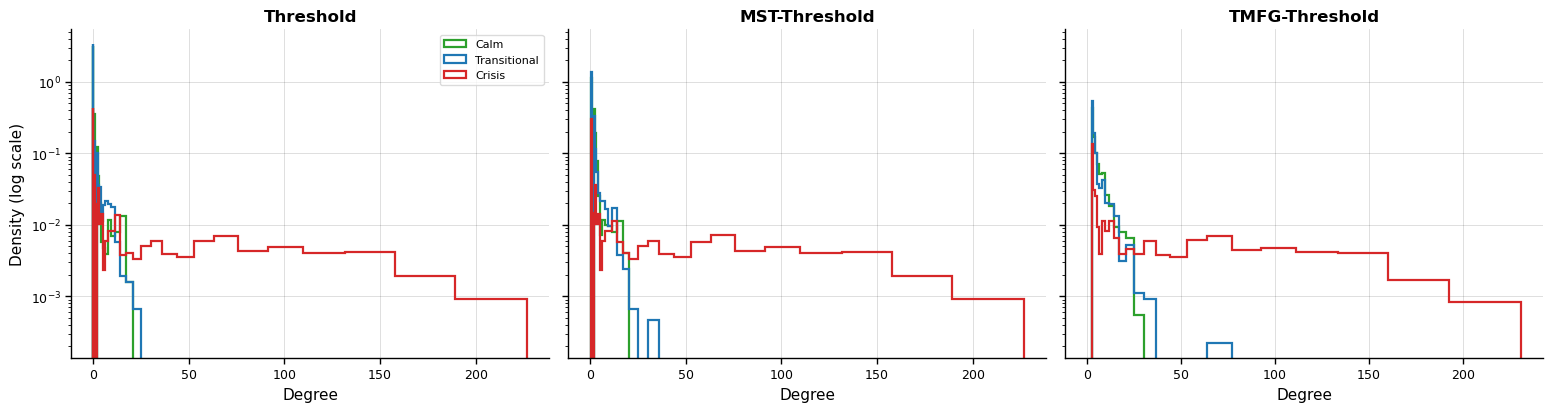

In [8]:
# Figure 3: degree distribution per construction, three periods overlaid (log-y; log1p-spaced bins per panel since Calm/Transitional and Crisis sit two orders of magnitude apart within every construction)
fig, axes = plt.subplots(1, len(GRAPH_TYPES), figsize=(5.2 * len(GRAPH_TYPES), 4.2), sharey=True)
for ax, graph_type in zip(axes, GRAPH_TYPES):
    panel_degrees = [degree_by_panel[(graph_type, p)] for p in REGIME_NAMES]
    max_degree = max(max(d) for d in panel_degrees)
    bins = np.expm1(np.linspace(0, np.log1p(max_degree), 31))
    for period_name, colour, degrees in zip(REGIME_NAMES, REGIME_PALETTE, panel_degrees):
        ax.hist(degrees, bins=bins, histtype="step", linewidth=1.6, color=colour, label=period_name, density=True)
    ax.set_xlabel("Degree")
    ax.set_yscale("log")
    ax.set_title(GRAPH_LABELS[graph_type], fontweight="bold")
    style_axis(ax, grid=True)
axes[0].set_ylabel("Density (log scale)")
axes[0].legend(loc="upper right", frameon=True, facecolor="white", edgecolor="lightgray", fontsize=8)
plt.tight_layout()
save_figure(fig, f"{IMAGES_DIR}/degree_distribution_by_period.png")
plt.show()

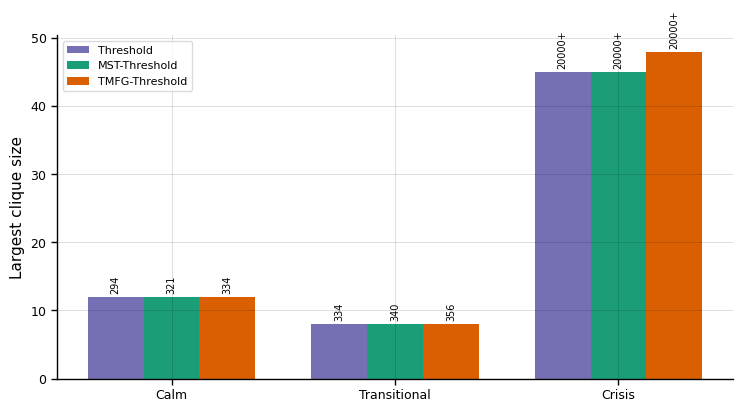

In [9]:
# Figure 4: largest clique size per construction x period (capped-enumeration count annotated above each bar)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
width = 0.25
x = np.arange(len(REGIME_NAMES))
for i, graph_type in enumerate(GRAPH_TYPES):
    sizes = [snapshot_df.loc[(GRAPH_LABELS[graph_type], p), "largest_clique"] for p in REGIME_NAMES]
    counts = [snapshot_df.loc[(GRAPH_LABELS[graph_type], p), "n_maximal_cliques"] for p in REGIME_NAMES]
    bars = ax.bar(x + (i - 1) * width, sizes, width, color=GRAPH_TYPE_COLOURS[graph_type], label=GRAPH_LABELS[graph_type])
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(count),
                ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(REGIME_NAMES)
ax.set_ylabel("Largest clique size")
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="lightgray", fontsize=8)
style_axis(ax, grid=True)
plt.tight_layout()
save_figure(fig, f"{IMAGES_DIR}/clique_statistics.png")
plt.show()

In [10]:
# Synthesis of the topology diagnostics above: how the three constructions behave across Calm, Transitional, and Crisis
print("""\
Density converges, baselines don't. Calm density: Threshold 0.005, MST-Threshold 0.009, TMFG-Threshold 0.019
(TMFG ~4x denser at baseline, by construction) -- but Crisis density converges to ~0.214-0.216 for all three.

Fragmentation is Threshold-specific. Threshold has 250 components in Calm, still 32 in Crisis; MST-/TMFG-Threshold
are always 1 component -- independently reproducing docs/math/eigencentrality.md's connectivity-guarantee
argument for restricting eigencentrality_sweep_raw.py to ["mst", "tmfg"].

Small-world collapse, where connectivity is guaranteed. MST-Threshold avg. path length: 12.5 -> 2.0
(Calm -> Crisis), diameter 31 -> 5; TMFG-Threshold 7.5 -> 1.9, diameter 20 -> 4. Threshold's own LCC-restricted
path length is non-monotonic (1.8 -> 3.4 -> 1.9) since who is in its LCC changes each period.

Assortativity flips sign: 0.57-0.66 (Calm) -> -0.09 (Crisis) for Threshold/MST-Threshold -- sector-hub homophily
replaced by flat, market-wide comovement.

Sector structure is what crisis destroys. NMI (communities vs. sector) falls monotonically Calm->Crisis for all
three constructions (0.61->0.29, 0.54->0.21, 0.47->0.24) and dips at every annotated crisis event above --
independent, topology-only corroboration that network structure carries regime information.

Clique enumeration itself is evidence. Counts stay in the low hundreds in Calm/Transitional, then blow past the
20,000 cap in every Crisis snapshot, for every construction -- direct combinatorial confirmation of
near-complete-graph collapse.

Limitations: single market/epoch length, one VIX-selected window per period rather than an ensemble
(Transitional's smaller largest-clique than Calm's shows why that matters), one community-detection algorithm.
""")

Density converges, baselines don't. Calm density: Threshold 0.005, MST-Threshold 0.009, TMFG-Threshold 0.019
(TMFG ~4x denser at baseline, by construction) -- but Crisis density converges to ~0.214-0.216 for all three.

Fragmentation is Threshold-specific. Threshold has 250 components in Calm, still 32 in Crisis; MST-/TMFG-Threshold
are always 1 component -- independently reproducing docs/math/eigencentrality.md's connectivity-guarantee
argument for restricting eigencentrality_sweep_raw.py to ["mst", "tmfg"].

Small-world collapse, where connectivity is guaranteed. MST-Threshold avg. path length: 12.5 -> 2.0
(Calm -> Crisis), diameter 31 -> 5; TMFG-Threshold 7.5 -> 1.9, diameter 20 -> 4. Threshold's own LCC-restricted
path length is non-monotonic (1.8 -> 3.4 -> 1.9) since who is in its LCC changes each period.

Assortativity flips sign: 0.57-0.66 (Calm) -> -0.09 (Crisis) for Threshold/MST-Threshold -- sector-hub homophily
replaced by flat, market-wide comovement.

Sector structure is w

In [11]:
# Interpretation: what Graph2Vec's WL-hashing likely captures, and why it would differ by construction (reasoned from graph2vec.py's mechanics plus the topology evidence above, no sweep output used)
print("""\
Graph2Vec labels every node by its raw degree, then hashes each node's label together with its sorted
neighbours' labels for wl_iterations=3 rounds, pooling the result into a Doc2Vec vocabulary (min_count=5) over
discrete, degree-rooted 3-hop tokens (graph2vec.py). It has no notion of sector, no notion of "scale" (only
discrete hashed tokens), and no access to anything beyond 3 hops.

Calm and Transitional are nearly indistinguishable topologically for every construction (mean degree barely
moves between them: Threshold 1.86 -> 1.93, MST 3.29 -> 3.30, TMFG 6.75 -> 6.59) -- the only sharp discontinuity
is (Calm+Transitional) vs. Crisis. Since WL tokens are purely local-structure hashes, Graph2Vec has almost no
genuine structural signal to separate Calm from Transitional regardless of construction -- separability is
realistically a two-way, not a clean three-way, story.

Threshold and MST-Threshold undergo a shape change, not just a scale change: clustering coefficient roughly
quadruples (~0.15-0.18 -> ~0.64), i.e. local neighbourhoods genuinely reorganise from sparse/tree-like to
clique-like. WL-hashing is discrete, not proportional -- a qualitative shape change like this produces an almost
entirely disjoint Calm-vs-Crisis vocabulary, a strong, clean signal for Doc2Vec to separate on.

TMFG-Threshold's clustering coefficient is regime-invariant (~0.73-0.74 throughout) -- its neighbourhoods stay
triangle-dense in both regimes; what changes is mostly degree magnitude, a scale shift. A hashing scheme with no
sense of proportionality represents scale-only shifts more diffusely (many discrete degree tokens spread across
a range) than a qualitative shape flip.

The one semantically interpretable structure Graph2Vec could latch onto -- sector clustering, visible directly
in Figure 1's node colours -- collapses in Crisis (the NMI finding computed above). Graph2Vec never sees sector
labels; any sector-related signal in its embedding is a byproduct of correlation topology, and that byproduct
disappears exactly when the market comoves. What a Crisis window's embedding captures is therefore closer to
"the market lost its sector structure" than any new higher-order pattern.

Assortativity's flip plausibly widens Crisis's WL vocabulary. Calm's strong assortativity (0.57-0.66) means a
node's neighbour-label multiset is homogeneous -- few, frequently-repeated WL tokens. Crisis's near-zero/negative
assortativity means neighbour-label multisets span the whole degree range -- combinatorially more distinct,
individually rarer tokens (consistent with the clique-count explosion above), exactly the profile at risk of
min_count/OOV filtering during training.

Working hypothesis, not a verified ranking: Threshold and MST-Threshold hand Graph2Vec a genuine, discrete
shape-level phase transition to key on (sparse/fragmented <-> dense/clique-like), while TMFG-Threshold's
regime-invariant clustering coefficient means its signal is carried more by degree magnitude than by structural
type -- a form of change WL-hashing represents more diffusely. Confirming this against actual detection
performance needs the sweep scripts' embeddings, deliberately out of scope here.
""")

Graph2Vec labels every node by its raw degree, then hashes each node's label together with its sorted
neighbours' labels for wl_iterations=3 rounds, pooling the result into a Doc2Vec vocabulary (min_count=5) over
discrete, degree-rooted 3-hop tokens (graph2vec.py). It has no notion of sector, no notion of "scale" (only
discrete hashed tokens), and no access to anything beyond 3 hops.

Calm and Transitional are nearly indistinguishable topologically for every construction (mean degree barely
moves between them: Threshold 1.86 -> 1.93, MST 3.29 -> 3.30, TMFG 6.75 -> 6.59) -- the only sharp discontinuity
is (Calm+Transitional) vs. Crisis. Since WL tokens are purely local-structure hashes, Graph2Vec has almost no
genuine structural signal to separate Calm from Transitional regardless of construction -- separability is
realistically a two-way, not a clean three-way, story.

Threshold and MST-Threshold undergo a shape change, not just a scale change: clustering coefficient roughly
quadruples

In [12]:
# Empirical edge-set containment check across every window (Threshold-in-both is guaranteed by construction via the union; MST-in-TMFG is not, since MST and TMFG are independently derived)
def edge_set(G):
    return {frozenset(e) for e in G.edges()}


n_windows = len(data[GRAPH_KEYS["threshold"]])
nesting_rows = []
for i in range(n_windows):
    t_edges = edge_set(data[GRAPH_KEYS["threshold"]][i])
    mst_edges = edge_set(data[GRAPH_KEYS["mst"]][i])
    tmfg_edges = edge_set(data[GRAPH_KEYS["tmfg"]][i])
    nesting_rows.append({
        "date": epoch_dates[i],
        "threshold_in_mst": t_edges <= mst_edges,
        "threshold_not_in_mst": len(t_edges - mst_edges),
        "threshold_in_tmfg": t_edges <= tmfg_edges,
        "threshold_not_in_tmfg": len(t_edges - tmfg_edges),
        "mst_in_tmfg": mst_edges <= tmfg_edges,
        "mst_not_in_tmfg": len(mst_edges - tmfg_edges),
        "n_mst_threshold_edges": len(mst_edges),
    })

nesting_df = pd.DataFrame(nesting_rows)
print(f"windows checked: {len(nesting_df)}")
print(f"Threshold subset of MST-Threshold:      {nesting_df['threshold_in_mst'].mean():.1%} of windows, "
      f"{nesting_df['threshold_not_in_mst'].sum()} violating edges total")
print(f"Threshold subset of TMFG-Threshold:     {nesting_df['threshold_in_tmfg'].mean():.1%} of windows, "
      f"{nesting_df['threshold_not_in_tmfg'].sum()} violating edges total")
print(f"MST-Threshold subset of TMFG-Threshold: {nesting_df['mst_in_tmfg'].mean():.1%} of windows, "
      f"{nesting_df['mst_not_in_tmfg'].sum()} violating edges total")
print()
print("MST-Threshold edges absent from TMFG-Threshold, per window (n_mst_threshold_edges is the MST-Threshold graph's total edge count, not the raw MST's n_stocks - 1 -- it grows with the threshold augmentation, same as any other window's edge count):")
print(nesting_df[["n_mst_threshold_edges", "mst_not_in_tmfg"]].describe().round(2))
print()
print("MST-Threshold is not a strict subset of TMFG-Threshold almost anywhere: MST and TMFG are independently "
      "derived from the distance/correlation matrix, so an MST edge forced by spanning-tree connectivity to a "
      "weakly-correlated pair has no reason to also be selected by TMFG's own greedy triangulation or clear the "
      "threshold. \"Nested network constructions\" is accurate only for the trivial Threshold-in-both relationship.")

windows checked: 629
Threshold subset of MST-Threshold:      100.0% of windows, 0 violating edges total
Threshold subset of TMFG-Threshold:     100.0% of windows, 0 violating edges total
MST-Threshold subset of TMFG-Threshold: 0.2% of windows, 32852 violating edges total

MST-Threshold edges absent from TMFG-Threshold, per window (n_mst_threshold_edges is the MST-Threshold graph's total edge count, not the raw MST's n_stocks - 1 -- it grows with the threshold augmentation, same as any other window's edge count):
       n_mst_threshold_edges  mst_not_in_tmfg
count                 629.00           629.00
mean                 3465.89            52.23
std                  6453.73            24.94
min                   374.00             0.00
25%                   698.00            36.00
50%                  1233.00            53.00
75%                  2159.00            69.00
max                 37716.00           108.00

MST-Threshold is not a strict subset of TMFG-Threshold almost anywh